<a href="https://colab.research.google.com/github/gaurikabehl0802/prunable-neural-network-from-scratch/blob/main/framework_for_geospatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install geopandas osmnx folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.6 MB/s eta 0:00:00


In [4]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

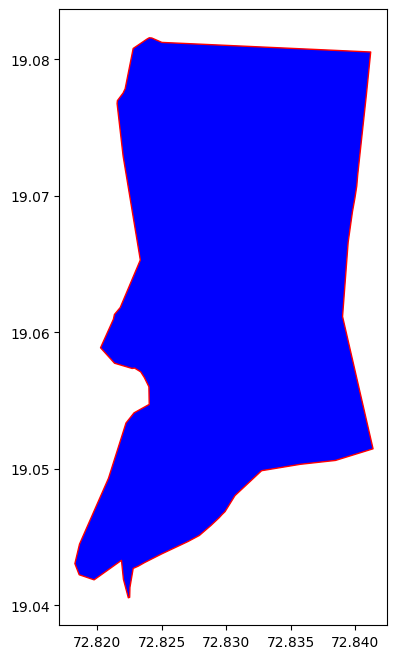

In [5]:
place = "Bandra West, Mumbai, India"

polygon = ox.geocode_to_gdf(place)

polygon

polygon.plot(figsize=(8,8), edgecolor='red', facecolor='blue')
plt.show()

In [6]:
#shop as a feature so depending on the number of shops determine how developed an area is to expand business
#more shops more developed area better reach

tags = {
    "shop": True
}

shops = ox.features_from_polygon(
    polygon.geometry.iloc[0],
    tags
)

shops.head()



geometry              name     shop  \
element id                                                                 
node    346619470   POINT (72.82638 19.04997)  Nattu Cyclewalla  bicycle   
        347146089   POINT (72.82699 19.05517)  J Hearsch and Co   bakery   
        1514451608  POINT (72.82521 19.07435)      Ahmed Bakery   bakery   
        1514451663  POINT (72.82596 19.07461)               NaN      tea   
        1641775277  POINT (72.82254 19.07165)      Salim Garage      car   

                   addr:city addr:postcode addr:street          opening_hours  \
element id                                                                      
node    346619470        NaN           NaN         NaN                    NaN   
        347146089     Mumbai        400050   Hill Road  Mo, We-Su 07:30-22:00   
        1514451608       NaN           NaN         NaN                    NaN   
        1514451663       NaN           NaN         NaN                    NaN   
        1641775277       NaN           NaN         NaN                    NaN   

                   payment:cash          phone addr:housename  ...  \
element id                                                     ...   
node    346619470           NaN            NaN            NaN  ...   
        347146089           yes  022 2643 5361            NaN  ...   
        1514451608          NaN            NaN            NaN  ...   
        1514451663          NaN            NaN            NaN  ...   
        1641775277          NaN            NaN            NaN  ...   

                   service:binding craft payment:apple_pay  \
element id                                                   
node    346619470              NaN   NaN               NaN   
        347146089              NaN   NaN               NaN   
        1514451608             NaN   NaN               NaN   
        1514451663             NaN   NaN               NaN   
        1641775277             NaN   NaN               NaN   

                   payment:contactless building payment:girocard  \
element id                                                         
node    346619470                  NaN      NaN              NaN   
        347146089                  NaN      NaN              NaN   
        1514451608                 NaN      NaN              NaN   
        1514451663                 NaN      NaN              NaN   
        1641775277                 NaN      NaN              NaN   

                   payment:maestro mobile note phone_1  
element id                                              
node    346619470              NaN    NaN  NaN     NaN  
        347146089              NaN    NaN  NaN     NaN  
        1514451608             NaN    NaN  NaN     NaN  
        1514451663             NaN    NaN  NaN     NaN  
        1641775277             NaN    NaN  NaN     NaN  

[5 rows x 76 columns]

In [7]:
print("Total Shops:", len(shops))

Total Shops: 558


In [8]:
#schools- indicator for development of a region- more schools, more people reside in that area
tags={"amenity":"school"}
schools=ox.features_from_polygon(polygon.geometry.iloc[0],tags)
schools.head()


geometry amenity  \
element id                                               
node    347125102      POINT (72.82621 19.055)  school   
        4247756492   POINT (72.82922 19.06148)  school   
        4303179586   POINT (72.83278 19.06084)  school   
        10878535991  POINT (72.83797 19.07905)  school   
        11296361349  POINT (72.82709 19.06114)  school   

                                                         name addr:postcode  \
element id                                                                    
node    347125102    Apostolic Carmel Convent (Girl's School)           NaN   
        4247756492                                 Safari Kid        400050   
        4303179586                Duruelo Convent High School           NaN   
        10878535991                Podar International School           NaN   
        11296361349          Learner's Academy I.C.S.E School           NaN   

                    addr:housenumber     addr:street source name:en building  \
element id                                                                     
node    347125102                NaN             NaN    NaN     NaN      NaN   
        4247756492               NaN             NaN    NaN     NaN      NaN   
        4303179586               NaN             NaN    NaN     NaN      NaN   
        10878535991      02267111111  Saraswati Road    AND     NaN      NaN   
        11296361349              NaN             NaN    NaN     NaN      NaN   

                    operator operator:type addr:city check_date ref:IN:UDISE  \
element id                                                                     
node    347125102        NaN           NaN       NaN        NaN          NaN   
        4247756492       NaN           NaN       NaN        NaN          NaN   
        4303179586       NaN           NaN       NaN        NaN          NaN   
        10878535991      NaN           NaN       NaN        NaN          NaN   
        11296361349      NaN           NaN       NaN        NaN          NaN   

                    religion addr:suburb phone website name:mr email  
element id                                                            
node    347125102        NaN         NaN   NaN     NaN     NaN   NaN  
        4247756492       NaN         NaN   NaN     NaN     NaN   NaN  
        4303179586       NaN         NaN   NaN     NaN     NaN   NaN  
        10878535991      NaN         NaN   NaN     NaN     NaN   NaN  
        11296361349      NaN         NaN   NaN     NaN     NaN   NaN

In [9]:
print("Total schools in the area: ",len(schools))

Total schools in the area:  25


In [10]:
#number of banks in an area: better money access and also developed area

tags={"amenity":"bank"}
Banks=ox.features_from_polygon(polygon.geometry.iloc[0],tags)
Banks.head()

geometry amenity  atm  \
element id                                                   
node    1501518125  POINT (72.83434 19.07149)    bank  yes   
        1501518150  POINT (72.83447 19.07586)    bank  yes   
        1501518157  POINT (72.83379 19.07522)    bank  yes   
        1514451614  POINT (72.82602 19.07446)    bank  yes   
        2068377754   POINT (72.8294 19.06138)    bank  yes   

                                   brand brand:wikidata  \
element id                                                
node    1501518125              Citibank        Q857063   
        1501518150            ICICI Bank       Q1653258   
        1501518157             IDBI Bank       Q3633485   
        1514451614  Indian Overseas Bank       Q2003611   
        2068377754             HDFC Bank        Q631047   

                            brand:wikipedia                  name short_name  \
element id                                                                     
node    1501518125              en:Citibank              Citibank       Citi   
        1501518150                      NaN            ICICI Bank      ICICI   
        1501518157             en:IDBI Bank             IDBI Bank       IDBI   
        1514451614  en:Indian Overseas Bank  Indian Overseas Bank        IOB   
        2068377754             en:HDFC Bank             HDFC Bank       HDFC   

                   addr:postcode   addr:street  ... brand:pnb brand:ur  \
element id                                      ...                      
node    1501518125           NaN           NaN  ...       NaN      NaN   
        1501518150        400054  Linking Road  ...       NaN      NaN   
        1501518157        400052           NaN  ...       NaN      NaN   
        1514451614           NaN           NaN  ...       NaN      NaN   
        2068377754           NaN           NaN  ...       NaN      NaN   

                   name:hi name:kn name:pa name:pnb name:ur official_name  \
element id                                                                  
node    1501518125     NaN     NaN     NaN      NaN     NaN           NaN   
        1501518150     NaN     NaN     NaN      NaN     NaN           NaN   
        1501518157     NaN     NaN     NaN      NaN     NaN           NaN   
        1514451614     NaN     NaN     NaN      NaN     NaN           NaN   
        2068377754     NaN     NaN     NaN      NaN     NaN           NaN   

                   bank building:levels  
element id                               
node    1501518125  NaN             NaN  
        1501518150  NaN             NaN  
        1501518157  NaN             NaN  
        1514451614  NaN             NaN  
        2068377754  NaN             NaN  

[5 rows x 38 columns]

In [11]:
print("Total banks in the area: ",len(Banks))

Total banks in the area:  76


In [12]:
#industrial areas to see the development of a region
tags={"landuse":"industrial"}
industries=ox.features_from_polygon(polygon.geometry.iloc[0],tags)
industries.head()

geometry  \
element id                                                              
way     125292494   POLYGON ((72.83827 19.05402, 72.83833 19.05367...   
        237027566   POLYGON ((72.82756 19.04767, 72.82873 19.04834...   
        1289185532  POLYGON ((72.83548 19.05069, 72.83536 19.0503,...   

                   capacity depot industrial     landuse  \
element id                                                 
way     125292494       200   bus      depot  industrial   
        237027566       NaN   NaN        NaN  industrial   
        1289185532      NaN   NaN        NaN  industrial   

                                         name operator   product  
element id                                                        
way     125292494       Bandra BEST Bus Depot     BEST       NaN  
        237027566   Mumbai Metro Casting Yard    MMRCL  concrete  
        1289185532                        NaN      NaN       NaN

In [13]:
print("industrial area: ",len(industries))

industrial area:  3


/tmp/ipykernel_1036/2299775611.py:12: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


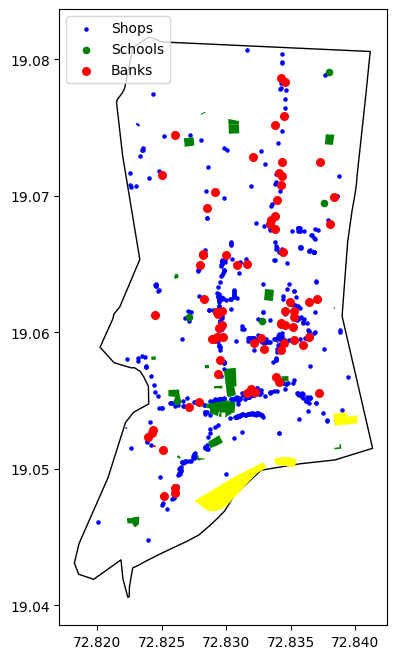

In [14]:
#plot to show shops, schools banks and industries
ax = polygon.plot(
    figsize=(8,8),
    edgecolor='black',
    facecolor='none'
)

shops.plot(ax=ax, color='blue', markersize=5, label='Shops')
schools.plot(ax=ax, color='green', markersize=20, label='Schools')
Banks.plot(ax=ax, color='red', markersize=30, label='Banks')
industries.plot(ax=ax,color='yellow',markersize=10,label='industries')

plt.legend()
plt.show()

In [15]:
import pandas as pd

summary = pd.DataFrame({
    "Feature": ["Shops", "Banks", "Schools", "Industries"],
    "Count": [
        len(shops),
        len(Banks),
        len(schools),
        len(industries)
    ]
})

summary

,Feature,Count
0,Shops,558
1,Banks,76
2,Schools,25
3,Industries,3


In [19]:
polygon_proj = polygon.to_crs(3857)

area_sqkm = polygon_proj.area.iloc[0]/1e6

print(area_sqkm)

print("shop density: ",len(shops)/area_sqkm)

print("banks density: ",len(Banks)/area_sqkm)

print("schools density: ",len(schools)/area_sqkm)

print("industries density: ",len(industries)/area_sqkm)

8.116921901493125
shop density:  68.74527151694717
banks density:  9.363155260372732
schools density:  3.079985283017346
industries density:  0.3695982339620816


(<Figure size 800x800 with 1 Axes>, <Axes: >)

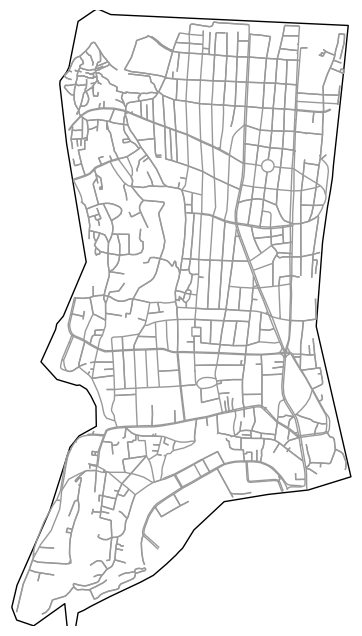

In [20]:
#road network : better road network, better connectivity and coverage , easier distribution
roads = ox.graph_from_polygon(
    polygon.geometry.iloc[0],
    network_type="drive"
)

fig, ax = plt.subplots(figsize=(8,8))

polygon.plot(ax=ax, facecolor='none')

ox.plot_graph(
    roads,
    ax=ax,
    node_size=0,
    show=False,
    close=False
)

/tmp/ipykernel_1036/2765316416.py:13: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


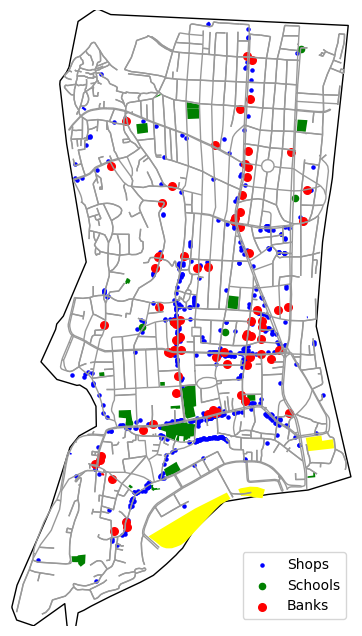

map of bandra west


In [22]:
ax = polygon.plot(
    figsize=(8,8),
    edgecolor='black',
    facecolor='none'
)

shops.plot(ax=ax, color='blue', markersize=5, label='Shops')
schools.plot(ax=ax, color='green', markersize=20, label='Schools')
Banks.plot(ax=ax, color='red', markersize=30, label='Banks')
industries.plot(ax=ax,color='yellow',markersize=10,label='industries')
ox.plot_graph(roads,ax=ax,node_size=0,show=False,close=False)

plt.legend()
plt.show()

print("map of bandra west")

In [29]:
import geopandas as gpd
import pandas as pd

points=gpd.GeoDataFrame(
    pd.concat([
        shops(['geometry'].assign(type='shop')),
        Banks(['geometry'].assign(type='bank')),
        schools(['geometry'].assign(type='school')),
        industries(['geometry'].assign(type='industry'))
    ]),ignore_index=True,
    geometry='geometry',
    crs=shops.crs
)

points['geometry']=points.geomtry.apply(lambda g: g if g.geom_type=='Point' else  g.centroid)

from scipy.stats import gaussian_kde
import numpy as np

x=points.geometry.x.values
y=points.geometry.y.values
kde=gaussian_kde([x,y])

xi,yi=np.ngrid[x.min():x.max():200j,y.min():y.max():200j]
zi=kde(np.vstack([xi.flatten(),yi.flatten()]))
zi=zi.reshape(xi.shape)

roads=ox.graph_from_polygon(polygon.geomtry.iloc[0],network_type='drive')
edges=ox.graph_to_gdfs(roads,nodes=False)

import matplotlib.pyplot as plt
import matplotlib as mpl

fig.ax=plt.subplots(figsize=(12,12))

cmap=plt.get_cmap('Y10rRd')
im=ax.imshow(
    zi,
    extent=[xi.min(),xi.max(),yi.min(),yi.max()],
    origin='lower',
    cmap=cmap,
    alpha=0.6
)
edges.plot(ax=ax,color='gray',linewidth=0.7,label='Road network',zorder=1)
polygon.boundary.plot(ax=ax,edgecolor='black',linewidth=2,label='Bandra West Boundary',zorder=3)

shops.plot(ax=ax,color='blue',markersize=6,marker='o',label='Shops',zorder=4)
schools.plot(ax=ax,color='green',markersize=8,marker='^',label='Schools',zorder=4)
Banks.plot(ax=ax,color='red',markersize=8,marker='s',label='Banks',zorder=4)
industries.plot(ax=ax,color='orange',markersize=8,marker='D',label='Industries',zorder=4)

ax.legen(loc="upper right",fontsize=10)

cbar=fig.colorbar(im,ax=ax,shrink=0.8,pad=0.02)
cbar.set_label('Composite feature density(Potential Index)',fontsize=12)

ax.set_title('Bandra west-- Prototype Catchment Potential(KDE Density)',fontsize=16,weight='bold')

ax.set_axis_off()
plt.tight_layout()
plt.show()



AttributeError: 'list' object has no attribute 'assign'

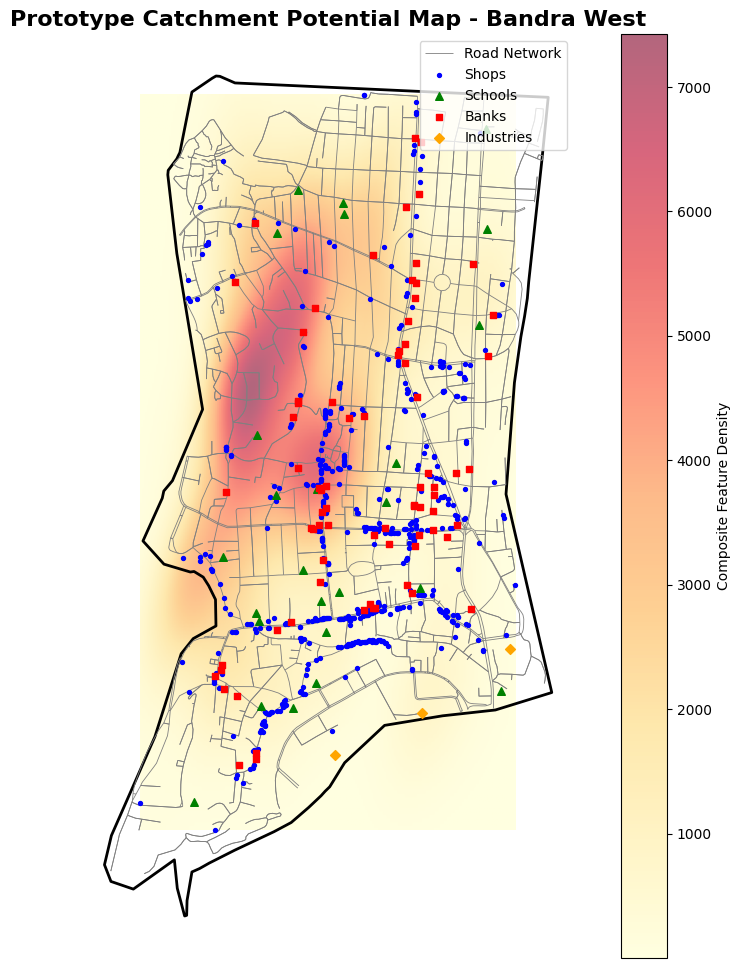

In [30]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
from scipy.stats import gaussian_kde

# =====================================================
# 1. Convert all geometries to Points (Centroids)
# =====================================================

def make_points(gdf):
    gdf = gdf.copy()

    gdf["geometry"] = gdf.geometry.apply(
        lambda g: g if g.geom_type == "Point" else g.centroid
    )

    return gdf

shops = make_points(shops)
schools = make_points(schools)
Banks = make_points(Banks)
industries = make_points(industries)

# =====================================================
# 2. Combine all points
# =====================================================

points = pd.concat([
    shops[["geometry"]],
    schools[["geometry"]],
    Banks[["geometry"]],
    industries[["geometry"]]
], ignore_index=True)

points = gpd.GeoDataFrame(
    points,
    geometry="geometry",
    crs=shops.crs
)

# =====================================================
# 3. KDE Heatmap
# =====================================================

x = points.geometry.x.values
y = points.geometry.y.values

kde = gaussian_kde([x, y])

xi, yi = np.mgrid[
    x.min():x.max():200j,
    y.min():y.max():200j
]

zi = kde(np.vstack([xi.flatten(), yi.flatten()]))

zi = zi.reshape(xi.shape)

# =====================================================
# 4. Download Road Network
# =====================================================

roads = ox.graph_from_polygon(
    polygon.geometry.iloc[0],
    network_type="drive"
)

edges = ox.graph_to_gdfs(
    roads,
    nodes=False
)

# =====================================================
# 5. Plot Everything
# =====================================================

fig, ax = plt.subplots(figsize=(12,12))

# Heatmap

im = ax.imshow(
    zi,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="YlOrRd",
    alpha=0.6
)

# Polygon Boundary

polygon.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

# Roads

edges.plot(
    ax=ax,
    color="gray",
    linewidth=0.6,
    label="Road Network",
    zorder=1
)

# Shops

shops.plot(
    ax=ax,
    color="blue",
    markersize=8,
    label="Shops",
    zorder=2
)

# Schools

schools.plot(
    ax=ax,
    color="green",
    marker="^",
    markersize=30,
    label="Schools",
    zorder=2
)

# Banks

Banks.plot(
    ax=ax,
    color="red",
    marker="s",
    markersize=25,
    label="Banks",
    zorder=2
)

# Industries

industries.plot(
    ax=ax,
    color="orange",
    marker="D",
    markersize=25,
    label="Industries",
    zorder=2
)

# Legend

plt.legend(loc="upper right")

# Colorbar

cbar = plt.colorbar(im)

cbar.set_label("Composite Feature Density")

# Title

plt.title(
    "Prototype Catchment Potential Map - Bandra West",
    fontsize=16,
    weight="bold"
)

plt.axis("off")

plt.show()